# Get DAILY Data for Basin

In [42]:
%load_ext autoreload
%autoreload 2

import json
import logging
from pathlib import Path

import geopandas as gpd
import pandas as pd
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import ConnectionType, DownloadMode, FileDownloader
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil

from utils.hydrology import Hydrology


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Constants

In [34]:
BASIN = "RioBranco"
STATION = 13600002

path = Path(f"/data/CN3S/basins/{BASIN}")
assert path.exists(), f"Path {path} does not exist"

## Load Basin boundaries

<Axes: >

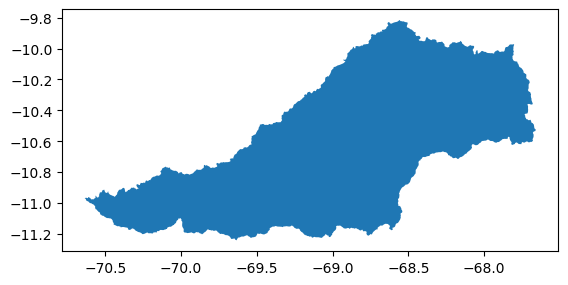

In [35]:
basin = gpd.read_parquet(f"/data/CN3S/basins/{BASIN}/DA_Station_{STATION}.parquet")
basin.plot()


In [36]:
# calculate the area in squared kilometers of basin (need to reproject to an equal-area projection first)
basin = basin.to_crs("epsg:32723")
basin["area_km2"] = basin.geometry.area / 1e6
print(f"Basin area: {basin['area_km2'].iloc[0]:.2f} km²")

Basin area: 27898.36 km²


In [37]:
data = {
    "station": STATION,
    "area": basin["area_km2"].iloc[0],
}

In [38]:
with (path / "metadata.json").open("w") as f:
    json.dump(data, f)

with (path / "metadata.json").open("r") as f:
    metadata = json.load(f)

metadata

{'station': 13600002, 'area': 27898.35854781605}

## Create Downloader

In [27]:
fd = FileDownloader(
    server=INPE_SERVER,
    connection_type=ConnectionType.HTTP,
    download_mode=DownloadMode.NO_UPDATE,
    log_level=logging.DEBUG,
)

downloader = Downloader(
    file_downloader=fd,
    local_folder="/data/CN3S/downloads",
    parsers=InpeParsers,
    log_level=logging.DEBUG,
)


Using wget through HTTP on: ftp.cptec.inpe.br


In [21]:
da = downloader.open_file("2026-05-01", InpeTypes.MONTHLY_ACCUM_YEARLY)
da

<xarray.DataArray 'pacum' (time: 1, latitude: 691, longitude: 551)> Size: 3MB
[380741 values with dtype=float64]
Coordinates:
  * longitude    (longitude) float64 4kB -85.05 -84.95 -84.85 ... -30.15 -30.05
  * latitude     (latitude) float64 6kB -56.15 -56.05 -55.95 ... 12.75 12.85
  * time         (time) datetime64[ns] 8B 2026-05-01T12:00:00
    spatial_ref  int64 8B 0

## Get DAILY MERGE Rain for Basin

Considering the size of the cube, we will split the rain in years then concatenate everything into one pandas dataframe. 

In [28]:
years = range(2000, 2027)
rain = pd.DataFrame()

for year in years:
    print(f"Processing year {year}...")

    cube_year = downloader.create_cube(
        f"{year}-01-01",
        f"{year}-12-31",
        InpeTypes.DAILY_RAIN,
    )
    cube_year_clipped = GISUtil.cut_cube_by_geoms(cube_year, basin.geometry)

    rain_year = cube_year_clipped.mean(dim=["latitude", "longitude"]).to_dataframe()
    rain_year = rain_year.drop(columns=["spatial_ref", "valid_time", "surface"])
    rain_year = rain_year.rename(columns={"rdp": "prec"})

    rain_year.to_parquet(f"/data/CN3S/basins/{BASIN}/Daily_Prec_{year}_{STATION}.parquet")

    rain = pd.concat([rain, rain_year], axis=0)

rain.to_parquet(f"/data/CN3S/basins/{BASIN}/Daily_Prec_{STATION}.parquet")

Processing year 2000...


Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...
Processing year 2026...


## Get DAILY discharge

In [43]:
hydro = Hydrology()

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code B7TGW249V to authenticate.


In [57]:
daily_q = hydro.get_discharge(STATION, "vazao")
daily_q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1967-08-08,13600002,2,15.20
1967-08-09,13600002,2,14.88
1967-08-10,13600002,2,14.27
1967-08-11,13600002,2,14.27
1967-08-12,13600002,2,14.27
...,...,...,...
2026-02-24,13600002,1,602.56
2026-02-25,13600002,1,630.80
2026-02-26,13600002,1,588.95


In [14]:
daily_q.to_parquet(f"/data/CN3S/basins/{BASIN}/Daily_Q_{STATION}.parquet")